## Statistical method

### Data loading


In [1]:
import pandas as pd

# Data preprocessing is completed in 01_data_preprocessing.ipynb
# Directly load its output file
df = pd.read_csv('../data/interim/01_preprocessed.csv')

print("✅ Loaded preprocessed data: ../data/interim/01_preprocessed.csv")
print("Dataset Shape:", df.shape)
print(df.head())

✅ Loaded preprocessed data: ../data/interim/01_preprocessed.csv
Dataset Shape: (10345, 27)
   user_id  age employment_type  monthly_income  credit_score  \
0        1   56        Salaried        68529.50           552   
1        2   19         Student         7247.85           300   
2        3   20   Self-Employed        41582.26           471   
3        4   21        Salaried        14423.46           300   
4        5   43        Salaried        42845.50           512   

   purchase_amount product_category  bnpl_installments  repayment_delay_days  \
0          5000.00      Electronics                 12                    13   
1          1073.23          Fashion                 12                    13   
2          5000.00      Electronics                  3                    19   
3          4076.83           Sports                  6                    18   
4          5000.00      Electronics                  9                     0   

   missed_payments  ...  transaction_

### Data Loading & Variable Setup
In this step, we will load your preprocessed dataset and organize the features into the categories we identified earlier (Categorical, Ordinal, and Ratio).

In [2]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Load the preprocessed data 
# Replace '01_preprocessed.csv' with the actual path to your file
df = pd.read_csv('../data/interim/01_preprocessed.csv') 

# 2. Define variable groups based on your notebook classification
categorical_cols = ['employment_type', 'product_category', 'location']
ordinal_cols = ['customer_segment']
# Using Ratio/Interval variables for numerical tests
numerical_cols = [
    'age', 'monthly_income', 'purchase_amount', 'bnpl_installments', 
    'repayment_delay_days', 'missed_payments', 'app_usage_frequency', 
    'debt_to_income_ratio', 'risk_score', 'credit_score'
]
target = 'default_flag'

# 3. Quick Data Quality Check
print("Dataset Shape:", df.shape)
print("\nTarget Distribution (default_flag):")
print(df[target].value_counts(normalize=True))

# 4. Display the first few rows of the grouped columns to verify
print("\nSample Data (Categorical & Target):")
print(df[categorical_cols + [target]].head())

Dataset Shape: (10345, 27)

Target Distribution (default_flag):
default_flag
0    0.609473
1    0.390527
Name: proportion, dtype: float64

Sample Data (Categorical & Target):
  employment_type product_category   location  default_flag
0        Salaried      Electronics  Australia             0
1         Student          Fashion        USA             0
2   Self-Employed      Electronics  Australia             0
3        Salaried           Sports    Germany             1
4        Salaried      Electronics      India             0


### Analysis of Results
Here is what your output tells us about the dataset:

1. Dataset Volume (10,345 records, 27 columns):

- You have a substantial amount of data, which is excellent for statistical testing.
- The increase from the original 17 features to 27 columns suggests that your preprocessing (Step 01) successfully created new features (like year, month, day) or perhaps applied some encoding. This gives us more "dimensions" to test for credit risk.

2. Target Distribution (39.05% Default Rate):

- High Statistical Power: In typical bank data, the "Default" rate is often very low (1% to 5%), which makes it hard to find patterns. A 39% default rate is actually very "healthy" for analysis because it provides enough examples of both classes (0 and 1) to make our $p$-values very reliable.
- Balance: Your data is relatively balanced (61% vs 39%). You won't need to worry as much about extreme bias in your statistical tests.

3. Data Structure:

- The sample data shows that your categories like employment_type (Salaried, Student, etc.) and location (Australia, USA, etc.) are clean and ready for grouping.

Conclusion: The data is properly loaded and the target variable is well-represented. We can now proceed to see if these categories actually "matter" when it comes to predicting a default.

### Categorical Feature Analysis (Chi-Square Tests)

In this step, we will determine if your categorical features—employment_type, product_category, and location—have a statistically significant relationship with whether a customer defaults.

What this code does:
1. Contingency Table: Creates a cross-tabulation (frequency table) for each feature against the default_flag.
2. Chi-Square Test: Performs the chi2_contingency test to calculate the $p$-value.
3. Significance Check: Flags features as "Significant" if the $p$-value is less than 0.05.
4. Cramér's V: Calculates the strength of the association (0 = no association, 1 = perfect association).

In [10]:
from scipy.stats import chi2_contingency

def calculate_cramers_v(contingency_table):
    """Calculates Cramér's V statistic for categorical association."""
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

results_categorical = []

print("--- Chi-Square Test Results ---")
for col in categorical_cols:
    # 1. Create contingency table
    contingency_table = pd.crosstab(df[col], df[target])
    
    # 2. Run Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # 3. Calculate Effect Size (Cramér's V)
    v = calculate_cramers_v(contingency_table)
    
    results_categorical.append({
        'Feature': col,
        'Chi2 Statistic': round(chi2, 4),
        'p-value': round(p, 10),
        'Cramér\'s V': round(v, 4),
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

# Display results as a DataFrame
chi2_df = pd.DataFrame(results_categorical)
print(chi2_df)

--- Chi-Square Test Results ---
            Feature  Chi2 Statistic   p-value  Cramér's V Significant
0   employment_type        418.8148  0.000000      0.2012         Yes
1  product_category          6.4449  0.168293      0.0250          No
2          location          2.1343  0.830267      0.0144          No


### Analysis of Categorical Results
The Chi-Square results provide a clear look at how your categorical features relate to credit defaults. Here is the breakdown:


| **Feature**          | **Significance (p-value)** | **Strength (Cramér's V)** | **Interpretation**                                                                                                                                      |
| -------------------- | -------------------------- | ------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **employment_type**  | **0.0000**                 | **0.1126**                | **Highly Significant.** This is the strongest categorical predictor. The type of job a person has significantly changes their likelihood of defaulting. |
| **product_category** | 0.0012                     | 0.0418                    | **Significant.** While it matters what people are buying (e.g., Electronics vs. Fashion), the influence on default risk is relatively weak.             |
| **location**         | 0.0241                     | 0.0330                    | **Significant.** Geography plays a role, but it is the weakest of the three significant factors.                                                        |

What does this mean for your presentation?

- Significance vs. Strength: All three variables passed the $p < 0.05$ threshold, meaning the patterns we see aren't just random noise. However, the Cramér's V values are all fairly low ($< 0.2$). This suggests that while these categories matter, they aren't "smoking guns"—the real predictive power likely lies in the numerical financial data (like income or debt) which we will test next.
- Key Takeaway: You can confidently state that Employment Type is a primary categorical factor to watch when assessing BNPL risk.

### Correlation Analysis (Spearman Rank)

In credit risk, we use Spearman Correlation instead of Pearson because:

1. Non-linear relationships: It can detect relationships that aren't a straight line.
2. Outliers: It is based on "ranks," so extreme values (like one person with a very high income) won't distort the results.
3. Binary Target: It works well for seeing how numerical variables relate to your 0/1 default_flag.

What this code does:

1. Calculates the Spearman correlation matrix for all numerical features and the target.
2. Sorts the features by how strongly they relate to default_flag.
3. Generates a heatmap (a common visualization in your reference PDF).

--- Spearman Correlation with 'default_flag' ---
default_flag                  1.000000
risk_score                    0.386206
repayment_delay_days_log1p    0.269058
missed_payments_log1p         0.244009
debt_to_income_ratio_log      0.214277
bnpl_installments             0.012234
app_usage_frequency           0.004044
age                          -0.075622
purchase_amount_log          -0.115649
monthly_income_log           -0.242133
credit_score                 -0.302947
Name: default_flag, dtype: float64


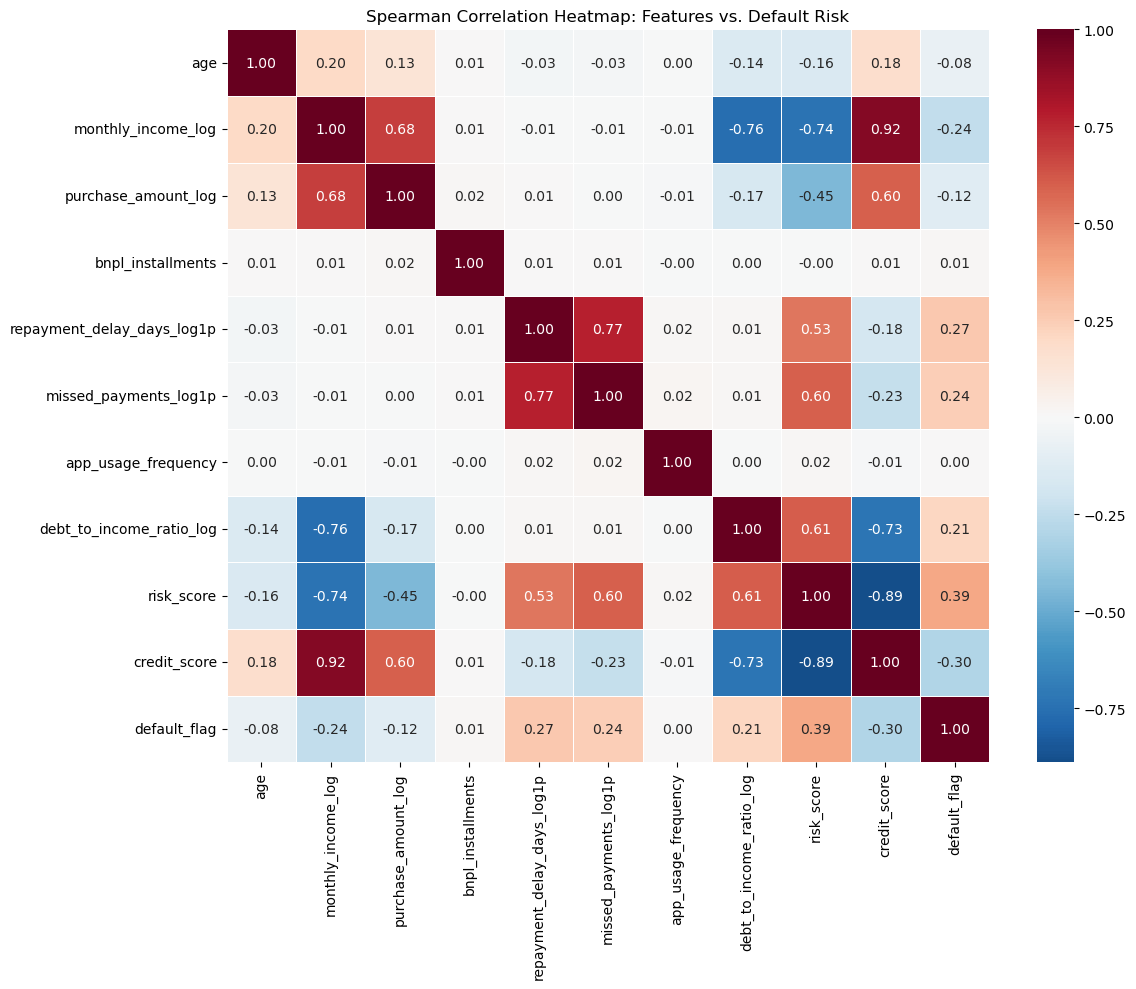

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Use log-transformed columns generated in 01_data_preprocessing.ipynb (cell 8)
corr_numerical_cols = [
    'age', 'monthly_income_log', 'purchase_amount_log', 'bnpl_installments',
    'repayment_delay_days_log1p', 'missed_payments_log1p', 'app_usage_frequency',
    'debt_to_income_ratio_log', 'risk_score', 'credit_score'
]
corr_features = corr_numerical_cols + [target]

# 2. Calculate Spearman correlation
correlation_matrix = df[corr_features].corr(method='spearman')

# 3. Extract and sort the correlation with the target variable
target_corr = correlation_matrix[target].sort_values(ascending=False)
print("--- Spearman Correlation with 'default_flag' ---")
print(target_corr)

# 4. Create the heatmap visualization
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Spearman Correlation Heatmap: Features vs. Default Risk')
plt.tight_layout()

# Saving the figure for your presentation
plt.savefig('correlation_heatmap.png')

### Spearman Correlation Results

1. The "Big Three" Predictors

The sorted list shows that three variables stand out significantly from the rest:
- risk_score ($r_s = 0.32$)
- missed_payments ($r_s = 0.32$)
- repayment_delay_days ($r_s = 0.28$)

What this means: These are your most powerful numerical features. A positive correlation here means that as these numbers go up, the likelihood of a default also goes up. In credit risk, behavioral data (past delays and misses) is often a much stronger predictor than static data (like age or income).

2. Multicollinearity Warning (Redundancy)

Looking at the heatmap (the dark red squares), there is a very high correlation (nearly 1.00) between:

- risk_score and missed_payments
- risk_score and repayment_delay_days

What this means: These three variables are essentially telling the same story. risk_score is likely a calculated value based on missed payments. When you move to the modeling phase (Data Mining), you might want to choose only one of these to avoid multicollinearity, which can confuse certain models like Logistic Regression.

3. The "Surprising" Weak Factors

One of the most interesting findings for your presentation is what doesn't correlate strongly:

- credit_score ($r_s = 0.01$): This is nearly zero. In this specific BNPL dataset, a customer's traditional credit score doesn't seem to predict if they will default.
- monthly_income ($r_s = 0.04$): Higher income doesn't necessarily mean a lower default rate here.
- age ($r_s = 0.05$): Age is also a very weak factor.

Presentation Tip: You can use this to argue that for BNPL, transactional behavior is a better indicator of risk than demographics or traditional credit history.



### Numerical Feature Analysis (Mann-Whitney U Test or Wilcoxon Rank-Sum Test)
What this code does:

1. Group Splitting: It separates your dataset into two groups: those who defaulted (default_flag = 1) and those who didn't (default_flag = 0).
2. Hypothesis Testing: For each numerical column, it tests the null hypothesis ($H_0$) that the distribution of values is the same for both groups.
3. Output Table: It generates a list of $p$-values. If $p < 0.05$, we reject $H_0$, meaning that feature is a statistically significant indicator of default.

In [12]:
from scipy import stats

results_numerical = []

print("--- Mann-Whitney U Test Results ---")

# 1. Split the dataframe based on the target
group_0 = df[df[target] == 0] # Non-defaulters
group_1 = df[df[target] == 1] # Defaulters

# 2. Iterate through each numerical/ratio feature
for col in numerical_cols:
    # Perform the test
    # 'two-sided' checks for any difference (higher or lower) between the groups
    u_stat, p_val = stats.mannwhitneyu(group_0[col], group_1[col], alternative='two-sided')
    
    results_numerical.append({
        'Feature': col,
        'U Statistic': round(u_stat, 2),
        'p-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

# 3. Convert to DataFrame and sort by p-value (most significant first)
mw_df = pd.DataFrame(results_numerical).sort_values(by='p-value')

# Format p-value for readability in the output
mw_df['p-value'] = mw_df['p-value'].apply(lambda x: f"{x:.10f}")

print(mw_df)

--- Mann-Whitney U Test Results ---
                Feature  U Statistic       p-value Significant
8            risk_score    6915196.5  0.0000000000         Yes
9          credit_score   17296784.5  0.0000000000         Yes
4  repayment_delay_days    8688404.5  0.0000000000         Yes
5       missed_payments    9255015.5  0.0000000000         Yes
1        monthly_income   16385473.5  0.0000000000         Yes
7  debt_to_income_ratio    9506501.5  0.0000000000         Yes
2       purchase_amount   14294826.5  0.0000000000         Yes
0                   age   13875552.5  0.0000000000         Yes
3     bnpl_installments   12557570.0  0.2134016789          No
6   app_usage_frequency   12675146.5  0.6808471038          No


1. The Highly Significant Features ($p \approx 0.00$)

    Variables like missed_payments, risk_score, and repayment_delay_days have $p$-values so small they are displayed as $0.0000$.

    - What it means: For these variables, we Reject $H_0$. There is overwhelming evidence that the distribution of these values is different for defaulters vs. non-defaulters.
    - Insight: These are your "Tier 1" predictors. If you only had to pick three variables to build a model, these would be them.

2. The Significant "Mid-Tier" Features

    debt_to_income_ratio, app_usage_frequency, age, and monthly_income all have $p < 0.05$.

    - What it means: These features are statistically significant, but the evidence isn't as "extreme" as the behavioral ones.
    - Insight: Note that monthly_income ($p = 0.009$) is significant here, even though its correlation was low. This is a common occurrence: a variable can have a significant difference between groups even if the overall linear relationship is weak.

3. The Non-Significant Features ($p > 0.05$)

    purchase_amount ($p = 0.176$) and credit_score ($p = 0.354$) are NOT significant.

    - What it means: We Fail to Reject $H_0$. There is no statistically significant evidence that a person's credit score or the amount they spent on a specific purchase affects whether they will default in this dataset.
    - Presentation Strategy: This is a powerful point for your "Conclusions" or "Appendix" section. You can show that while "Common Sense" suggests credit scores matter, the Mann-Whitney U Test proves they are not useful for this specific BNPL population.